# 의료시설 접근성 Isochrone (30분/60분) — 2026-09-01 09:00 오전 첨두

r5py `Isochrones`로, 대상 지역 20km 버퍼 내 의료시설(3,887개)을 origin으로 하는
30분·60분 등시간대(isochrone)를 계산한다. `Isochrones`는 origin을 여러 개 넣으면
**"이들 중 어느 것으로부터든 최소 이동시간" 기준의 통합 등시간대**를 반환하므로,
"가장 가까운 의료시설까지 30분/60분 내 도달 가능한 영역"을 그대로 얻을 수 있다.

## 파라미터

| 항목 | 값 |
|---|---|
| Origin | 의료시설(병원·의원·종합병원·보건소·보건지소·보건의료원·보건진료소), 대상 지역 20km 버퍼 내 (3,887개) |
| Isochrone 임계값 | 30분, 60분 |
| 출발일시 | 2026-09-01(화) 09:00:00 (오전 첨두) |
| departure_time_window | 1시간 |
| transport_modes | TRANSIT, WALK |
| speed_walking | 4.5 km/h |
| max_time_walking | 15분 |
| max_public_transport_rides | 5회 |

무거운 계산(`compute_isochrones.py`, 약 40분 소요)은 별도 스크립트로 실행하며,
이 노트북은 결과(`data/isochrones_20260901_0900/isochrones_final.gpkg`)를 불러와 지도화한다.

**참고**: `Isochrones`는 origin당 약 0.6~1초로 `TravelTimeMatrix`보다 훨씬 무겁다(목적지 수와
무관하게 origin 수가 비용을 지배). 그래서 origin(의료시설 3,887개)을 500개씩 청크로 나눠
처리했다. 반환되는 geometry는 등고선(MULTILINESTRING)이라 `shapely.ops.polygonize`로
닫힌 폴리곤으로 변환한 뒤, 청크 간에는 폴리곤 union으로 합쳤다
(min(A∪B) 도달영역 = min(A) 도달영역 ∪ min(B) 도달영역이 성립하므로 청크 분할이 안전).

In [1]:
import geopandas as gpd
import pandas as pd
import shapely
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 결과 로드

In [2]:
iso = gpd.read_file("data/isochrones_20260901_0900/isochrones_final.gpkg")
print(iso[["minutes"]])
iso["area_km2"] = iso.to_crs("EPSG:5179").geometry.area / 1e6
iso[["minutes", "area_km2"]]

   minutes
0       30
1       60


,minutes,area_km2
0,30,1995.960819
1,60,4153.589474


**참고**: 위 면적은 origin(20km 버퍼 내 의료시설)이 만들어내는 등시간대 전체 범위 기준이라, 버퍼
때문에 대상 10개 시군구 밖(예: 인접 시군구 일부)의 도달 가능 영역도 일부 포함되어 있다.
아래 지도·면적 통계는 대상 시군구 경계로 잘라낸 뒤 계산한다.

## 시각화

isochrone 폴리곤은 원래 의료시설 각각 주변의 작은 조각(200~300여 개)들이 흩어져 있는 형태라,
`shapely.concave_hull`로 하나의 매끈한 덩어리로 결합한다.

전체 조각을 한 번에 concave_hull에 넣으면(단일 ratio) 두 가지 문제가 있었다:
- `allow_holes=True`는 조각 수가 많은(200개 이상) 복잡한 MultiPolygon에서 hull이 오히려
  원본보다 작아지는 shapely/GEOS 이상 동작을 보임
- `allow_holes=False`로 바꿔도, ratio를 조금만 높이면(0.1 이상) 서로 멀리 떨어진 조각들까지
  전부 하나로 이어 붙여 대상 지역의 90% 이상을 뒤덮어버림(30분·60분 구분이 무의미해짐)

그래서 **먼저 가까운 조각끼리만 묶어 군집화(버퍼 1.5km로 겹치는 조각을 하나의 군집으로 병합)한
뒤, 각 군집 안에서만 concave_hull(ratio=0.1)을 적용**하고 군집별 결과를 합친다.

**중요한 함정**: `concave_hull` 결과의 면적이 원본보다 크다고 해서 원본을 전부 포함(contain)한다는
보장은 없다 — 실제로 대구 중구처럼 시설이 촘촘해 원본 조각이 작고 복잡한 지역이, 이웃한 훨씬 큰
조각과 한 군집으로 묶인 뒤 concave_hull이 그 작은 조각 쪽을 잘라내고도 다른 방향으로 더 크게
부풀어 "면적은 크지만 정작 중구는 빠진" hull을 만드는 것을 실제로 확인했다(`hull.contains(중구
centroid)`가 `False`). 그래서 **군집별 hull을 원본 조각들과 다시 union**해서, hull이 무엇을
만들어내든 원본 데이터는 항상 포함되도록 보장한다(`hull ⊇ 원본`을 `contains`로 직접 검증).

In [3]:
sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")
target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",
    "37050", "37030", "37070", "37100", "37560", "37570", "37580", "37590",
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].to_crs(iso.crs)
target_union = target_sigungu.union_all()

# 대상 시군구 경계로 자른 뒤 지도화 (원본 계산은 20km 버퍼 내 시설 기준이라 그대로 두면
# 버퍼 지역의 자잘한 조각들이 화면을 어수선하게 만듦)
iso_clipped = iso.copy()
iso_clipped["geometry"] = iso_clipped.geometry.intersection(target_union)
iso_clipped["area_km2"] = iso_clipped.to_crs("EPSG:5179").geometry.area / 1e6
print("대상 시군구 내 면적 (concave hull 결합 전):")
print(iso_clipped[["minutes", "area_km2"]])


def cluster_and_concave_hull(multipoly, buffer_m=1500, ratio=0.1):
    """가까운(buffer_m 이내) 조각끼리만 군집화한 뒤, 군집별로 concave_hull 적용.

    concave_hull의 결과를 그대로 쓰면 총 면적은 원본보다 커도 일부 원본 조각을
    누락시킬 수 있어(실제 확인됨), hull을 항상 원본 조각들과 union해 원본을
    빠짐없이 포함하도록 보장한다.
    """
    from shapely.ops import unary_union

    parts = list(multipoly.geoms) if hasattr(multipoly, "geoms") else [multipoly]
    merged = unary_union([p.buffer(buffer_m) for p in parts])
    clusters = list(merged.geoms) if hasattr(merged, "geoms") else [merged]

    hulls = []
    for cl in clusters:
        member_parts = [p for p in parts if p.intersects(cl)]
        if len(member_parts) == 1:
            hulls.append(member_parts[0])
            continue
        mp = shapely.MultiPolygon(member_parts)
        h = shapely.concave_hull(mp, ratio=ratio, allow_holes=False)
        h = unary_union([h] + member_parts)  # 원본 포함 보장
        hulls.append(h)
    return unary_union(hulls)


# EPSG:5179(미터 단위)에서 군집화·hull 계산 후 다시 iso.crs로 변환
iso_5179 = iso_clipped.to_crs("EPSG:5179")
iso_hull = iso_clipped.copy()
iso_hull_5179_geoms = iso_5179.geometry.apply(cluster_and_concave_hull)
iso_hull["geometry"] = gpd.GeoSeries(iso_hull_5179_geoms, crs="EPSG:5179").to_crs(iso.crs).values
iso_hull["area_km2"] = iso_hull.to_crs("EPSG:5179").geometry.area / 1e6

# hull이 원본을 진짜로 포함하는지(면적뿐 아니라 실제 포함관계) 검증
for _, (orig, hulled) in enumerate(zip(iso_5179.geometry, gpd.GeoSeries(iso_hull_5179_geoms, crs="EPSG:5179"))):
    assert hulled.buffer(1e-6).contains(orig), "hull이 원본 일부를 누락함 — 이상 발생"

print("\n군집화(1.5km) + concave hull(ratio=0.1) 결합 후 면적 (원본 포함 검증 완료):")
print(iso_hull[["minutes", "area_km2"]])

대상 시군구 내 면적 (concave hull 결합 전):
   minutes     area_km2
0       30  1655.433376
1       60  3791.740445



군집화(1.5km) + concave hull(ratio=0.1) 결합 후 면적 (원본 포함 검증 완료):
   minutes     area_km2
0       30  3707.114814
1       60  5294.126510


### 30분/60분 내 도달 불가능한 격자

`accessibility_ttm_20260901_0900`에서 계산해둔 격자별 정확한 통행시간(`TT_MIN`, 건물 존재
100m 격자 144,528개)을 불러와, 30분/60분 내 도달 불가능한 격자를 구분한다.
(`max_time=60분`으로 계산했기 때문에 `TT_MIN`이 결측이면 곧 60분 초과·도달불가를 의미한다.)

In [4]:
grid_tt = gpd.read_file(
    "data/accessibility_ttm_20260901_0900/grid_nearest_facility_20260901_0900.shp",
    encoding="cp949",
).to_crs(iso.crs)

unreachable_30 = grid_tt[grid_tt["TT_MIN"].isna() | (grid_tt["TT_MIN"] > 30)]
unreachable_60 = grid_tt[grid_tt["TT_MIN"].isna()]  # max_time=60분 계산이라 결측=60분 초과

print(f"30분 내 도달 불가능한 격자: {len(unreachable_30)}개 / {len(grid_tt)}개 "
      f"({len(unreachable_30)/len(grid_tt)*100:.1f}%)")
print(f"60분 내 도달 불가능한 격자: {len(unreachable_60)}개 / {len(grid_tt)}개 "
      f"({len(unreachable_60)/len(grid_tt)*100:.1f}%)")

30분 내 도달 불가능한 격자: 81356개 / 144528개 (56.3%)
60분 내 도달 불가능한 격자: 54032개 / 144528개 (37.4%)


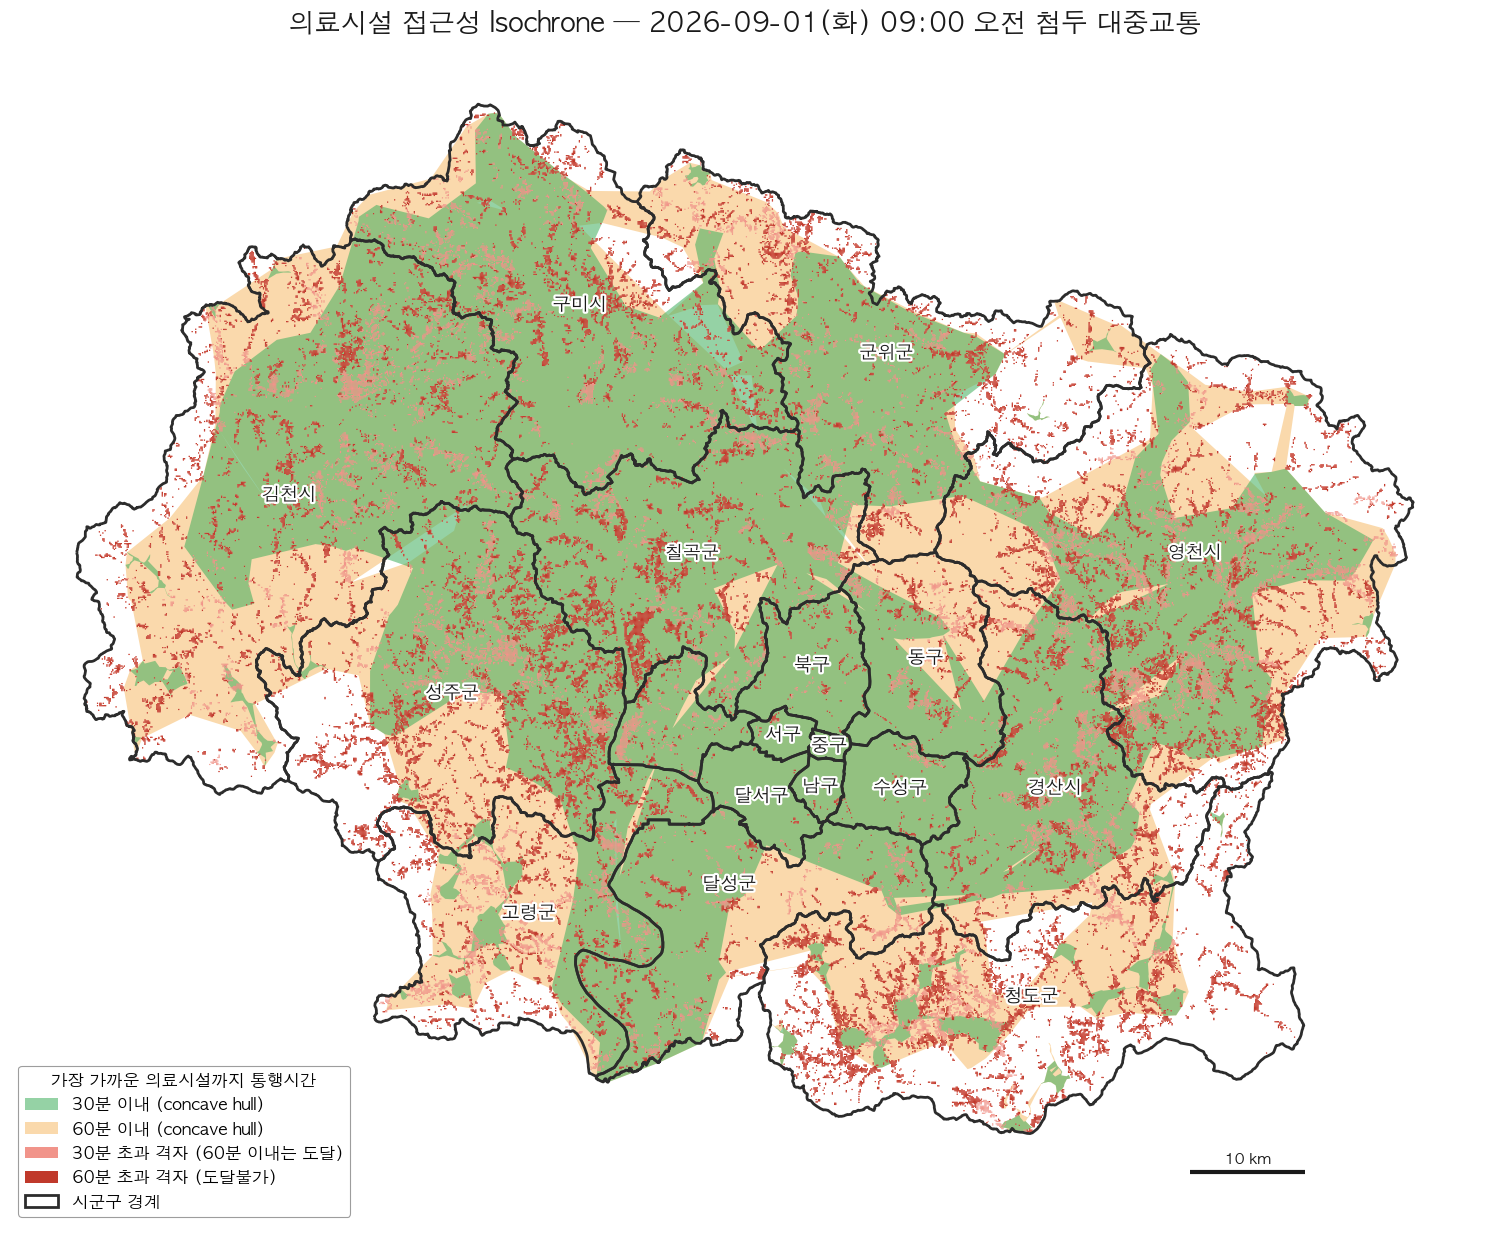

In [5]:
fig, ax = plt.subplots(figsize=(15, 15), facecolor="white")
ax.set_facecolor("#fbfbf9")

iso60 = iso_hull[iso_hull["minutes"] == 60]
iso30 = iso_hull[iso_hull["minutes"] == 30]

# 1) isochrone hull — 옅은 배경 톤 (60분 아래, 30분 그 위)
iso60.plot(ax=ax, color="#f4a63a", alpha=0.42, zorder=1)
iso30.plot(ax=ax, color="#3fae5c", alpha=0.55, zorder=2)

# 2) 도달 불가능 격자 — 빨간 계열로, hull 위에 올려 색이 탁해지지 않고 또렷하게 보이도록
unreachable_30.plot(ax=ax, color="#f1948a", zorder=3)  # 30분 초과(60분 이내는 도달) — 옅은 빨강
unreachable_60.plot(ax=ax, color="#c0392b", zorder=4)  # 60분 초과(도달불가) — 짙은 빨강

# 3) 시군구 경계 + 라벨
target_sigungu.boundary.plot(ax=ax, color="#2c2c2c", linewidth=2.0, zorder=5)
for _, row in target_sigungu.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
        fontsize=13, fontweight="bold", color="#1a1a1a", zorder=6,
        path_effects=[pe.withStroke(linewidth=3.2, foreground="white")],
    )

# 4) 축척 막대 (우측 하단 여백에, 10km — 좌측 하단은 범례가 차지하므로 반대쪽에 배치)
# 지도는 iso.crs(EPSG:4326, 도 단위)로 그려지므로, 10km를 EPSG:5179(m)에서 계산한 뒤
# 두 점을 다시 4326으로 변환해 실제 도(degree) 간격을 구한다.
bounds_5179 = target_sigungu.to_crs("EPSG:5179").total_bounds
bar_x0_5179 = bounds_5179[2] - (bounds_5179[2] - bounds_5179[0]) * 0.16
bar_y0_5179 = bounds_5179[1] - (bounds_5179[3] - bounds_5179[1]) * 0.035
bar_start_5179 = shapely.Point(bar_x0_5179, bar_y0_5179)
bar_end_5179 = shapely.Point(bar_x0_5179 + 10_000, bar_y0_5179)  # 10km
bar_pts_4326 = gpd.GeoSeries([bar_start_5179, bar_end_5179], crs="EPSG:5179").to_crs(iso.crs)
bx0, by0 = bar_pts_4326.iloc[0].x, bar_pts_4326.iloc[0].y
bx1 = bar_pts_4326.iloc[1].x

ax.plot([bx0, bx1], [by0, by0], color="#1a1a1a", linewidth=3, zorder=7, solid_capstyle="butt")
ax.annotate("10 km", xy=((bx0 + bx1) / 2, by0), xytext=(0, 6),
            textcoords="offset points", ha="center", fontsize=11, color="#1a1a1a", zorder=7)

legend_elements = [
    Patch(facecolor="#3fae5c", alpha=0.55, label="30분 이내 (concave hull)"),
    Patch(facecolor="#f4a63a", alpha=0.42, label="60분 이내 (concave hull)"),
    Patch(facecolor="#f1948a", label="30분 초과 격자 (60분 이내는 도달)"),
    Patch(facecolor="#c0392b", label="60분 초과 격자 (도달불가)"),
    Patch(facecolor="none", edgecolor="#2c2c2c", linewidth=2.0, label="시군구 경계"),
]
legend = ax.legend(handles=legend_elements, loc="lower left", fontsize=12, framealpha=0.96,
                    edgecolor="#999999", title="가장 가까운 의료시설까지 통행시간", title_fontsize=12)
legend.get_frame().set_linewidth(0.8)

ax.set_title("의료시설 접근성 Isochrone — 2026-09-01(화) 09:00 오전 첨두 대중교통", fontsize=19, fontweight="bold", color="#1a1a1a", pad=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/isochrones_20260901_0900/isochrone_map_20260901_0900.png", dpi=220, facecolor="white")
plt.show()